# Palm Anemia Classification  Data Preparation Module

Prepares a 3-class severity dataset (Normal, Leve/Mild, Moderado/Moderate)
from palm videos  extending the GLANCE Palm Cohort's Anemia category
(previously image-only, Ghana dataset) with a second, independent
mobile-captured source.

**Dataset source (research paper):** [Non-invasive multimodal dataset for
the detection of iron deficiency anemia in young adults — RCSI, 2025](https://revistas.unsm.edu.pe/index.php/rcsi/article/view/955)
(Valles-Coral et al., DOI: 10.51252/rcsi.v5i2.955, CC BY 4.0)

**Note:** data obtained directly from the authors. This is the same
source used for the Nail-Anemia notebook, but uses the `palmas`
(palm video) folder instead of `unas` (nail photos).

## What this notebook does

1. **Load videos + metadata**  909 patients in `metadata.csv`, 829
   have a linked palm video (`PALMAS` column). Videos pre-sorted into
   `Normal` / `Leve` / `Moderada` folders by severity.

2. **Join folder videos with metadata** by patient ID  829 of 833
   folder videos matched; 4 unmatched extras (duplicate `_2` second
   videos with no metadata row) were dropped.

3. **Kept 3-class labels as-is** (Normal / Leve / Moderado), consistent
   with the Nail-Anemia notebook's approach.

4. **Middle-frame extraction**  each ~10.7s, 1440x1440, 30fps video
   was reduced to a single representative frame (the temporal midpoint,
   assumed most stable). No bounding boxes or body-location info were
   needed since the palm fills most of the frame directly.

5. **Auto-crop + resize**  cropped the dark background and resized to
   224x224.

6. **Artifact check**  0% across all 3 classes (genuine studio
   backdrop, not an export artifact).

**Final output:** `df_success` dataframe (829 images, 1 per patient)
with `final_path` column at `/kaggle/working/peru_palm_final/`, saved
as `/kaggle/working/peru_palm_final_clean.csv`.

In [1]:
#Step 0: Dataset Source Configuration & Path Verification
DATASET_META = {
    "dataset_name": "Non-Invasive Multimodal Anemia Dataset (Peru/UNSM) - Palm Videos",
    "dataset_url": "https://revistas.unsm.edu.pe/index.php/rcsi/article/view/955",
    "kaggle_slug": "<your-username>/peru-palm-anemia",
    "kaggle_input_path": "/kaggle/input/datasets/shahrozkhalid11/peru-palm-anemia-dataset",
    "surface": "Hand/Palm",
    "target_classes": ["Normal", "Leve", "Moderada"]
}

from pathlib import Path
DATASET_ROOT = Path(DATASET_META["kaggle_input_path"])

if not DATASET_ROOT.exists():
    DATASET_ROOT = Path(f"/kaggle/input/{DATASET_META['kaggle_slug'].split('/')[-1]}")

if not (DATASET_ROOT / "palmas").exists():
    nested = DATASET_ROOT / DATASET_ROOT.name
    if (nested / "palmas").exists():
        DATASET_ROOT = nested
    else:
        # try any single nested folder
        subdirs = [p for p in DATASET_ROOT.iterdir() if p.is_dir()]
        if len(subdirs) == 1 and (subdirs[0] / "palmas").exists():
            DATASET_ROOT = subdirs[0]

assert (DATASET_ROOT / "palmas").exists(), f"'palmas' folder not found under: {DATASET_ROOT}"

print(f"Verified: {DATASET_META['dataset_name']}")
print(f"Mounted Path: {DATASET_ROOT}")

Verified: Non-Invasive Multimodal Anemia Dataset (Peru/UNSM) - Palm Videos
Mounted Path: /kaggle/input/datasets/shahrozkhalid11/peru-palm-anemia-dataset/peru-palm-anemia


In [2]:
#Step 1  Explore Folder Structure (Palm Videos + Metadata)
import pandas as pd

meta = pd.read_csv(DATASET_ROOT / "metadata.csv")
print(f"Total metadata rows: {len(meta)}")
print(f"Rows with non-null PALMAS (palm video filename): {meta['PALMAS'].notna().sum()}")

# severity counts among patients WITH a palm video
has_palm = meta[meta['PALMAS'].notna()]
print(f"\nSeverity counts (only patients WITH palm video, n={len(has_palm)}):")
print(f"  Normal: {has_palm['Normal'].sum()}")
print(f"  Leve: {has_palm['Leve'].sum()}")
print(f"  Moderado: {has_palm['Moderado'].sum()}")

Total metadata rows: 909
Rows with non-null PALMAS (palm video filename): 829

Severity counts (only patients WITH palm video, n=829):
  Normal: 560
  Leve: 197
  Moderado: 72


In [3]:
#Step 2  Load Metadata + Video-Count Cross-Check
palmas_dir = DATASET_ROOT / "palmas"

records = []
for cls_dir in sorted(palmas_dir.iterdir()):
    if not cls_dir.is_dir():
        continue
    for f in cls_dir.iterdir():
        if f.is_file() and f.suffix.lower() in [".mp4", ".mov", ".avi"]:
            patient_id = f.stem
            records.append({"patient_id": patient_id, "path": str(f),
                             "filename": f.name, "folder_severity": cls_dir.name})

vid_df = pd.DataFrame(records)
print(f"Videos found in folders: {len(vid_df)}")
print(vid_df["folder_severity"].value_counts())

# join with metadata on patient_id / ID
merged = vid_df.merge(meta, left_on="patient_id", right_on="ID", how="left", indicator=True)
print(f"\nMerge result:")
print(merged["_merge"].value_counts())

unmatched = merged[merged["_merge"] == "left_only"]
print(f"\nVideos with NO matching metadata row: {len(unmatched)}")
if len(unmatched) > 0:
    print(unmatched[["patient_id", "folder_severity"]].head(10))

df = merged[merged["_merge"] == "both"].drop(columns=["_merge"]).reset_index(drop=True)
df["class_name"] = df["folder_severity"].replace({"Moderada": "Moderado"})
print(f"\nFinal joined dataset: {len(df)} videos")
print(df["class_name"].value_counts())

Videos found in folders: 833
folder_severity
Normal      556
  Leve      203
Moderada     74
Name: count, dtype: int64

Merge result:
_merge
both          829
left_only       4
right_only      0
Name: count, dtype: int64

Videos with NO matching metadata row: 4
    patient_id folder_severity
23     ID651_2            Leve
145    ID451_2            Leve
313    ID370_2          Normal
373    ID632_2          Normal

Final joined dataset: 829 videos
class_name
Normal      554
  Leve      201
Moderado     74
Name: count, dtype: int64


In [4]:
#Step 4  Clean Class Labels (Normal / Leve / Moderado)
df["class_name"] = df["folder_severity"].str.strip().replace({"Moderada": "Moderado"})
print(df["class_name"].value_counts())

class_name
Normal      554
Leve        201
Moderado     74
Name: count, dtype: int64


In [5]:
#Step 5  Inspect Sample Video (FPS, Duration, Resolution)
import cv2

sample_video_path = df.iloc[0]["path"]
cap = cv2.VideoCapture(sample_video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration = frame_count / fps if fps > 0 else 0

print(f"Sample video: {df.iloc[0]['filename']}")
print(f"FPS: {fps}, Total frames: {frame_count}, Duration: {duration:.1f}s")
print(f"Resolution: {width}x{height}")

cap.release()

Sample video: ID601.mp4
FPS: 30.007790184367696, Total frames: 321.0, Duration: 10.7s
Resolution: 1440x1440


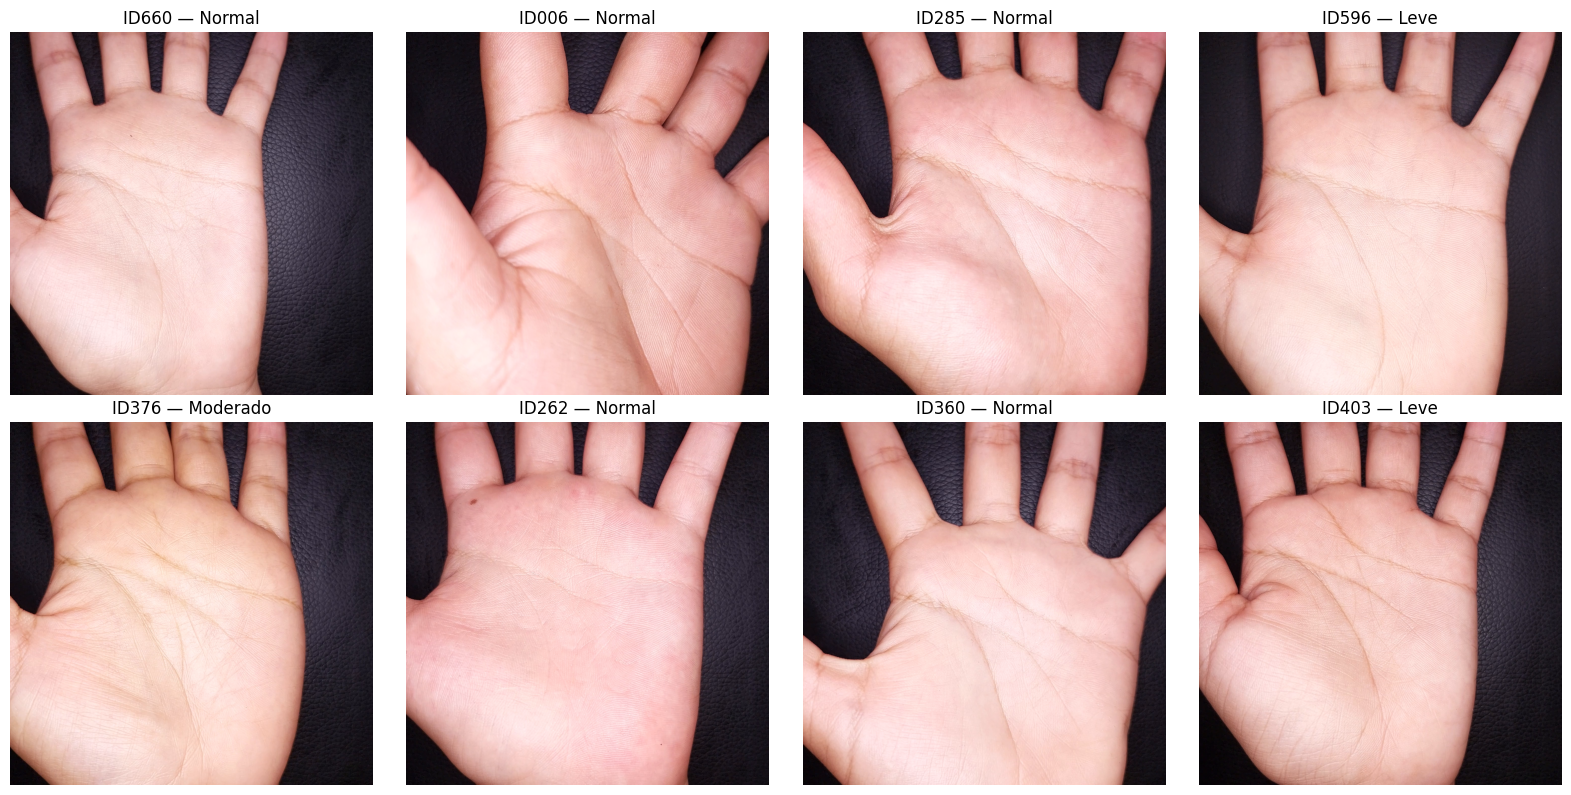

In [6]:
#Step 6  Visual Check: Middle-Frame Extraction on Samples
import matplotlib.pyplot as plt
import cv2

def extract_middle_frame(video_path):
    cap = cv2.VideoCapture(video_path)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    middle_idx = frame_count // 2
    cap.set(cv2.CAP_PROP_POS_FRAMES, middle_idx)
    ret, frame = cap.read()
    cap.release()
    return frame if ret else None

sample = df.sample(8, random_state=2)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    frame = extract_middle_frame(row["path"])
    if frame is not None:
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{row['patient_id']} — {row['class_name']}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [7]:
#Step 7  Extract Middle Frame + Auto-Crop + Resize (Full Dataset)
from pathlib import Path

OUTPUT_DIR = Path("/kaggle/working/peru_palm_final")
IMG_SIZE = (224, 224)

def auto_crop_content(img, dark_thresh=15):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask = gray > dark_thresh
    if mask.sum() == 0:
        return img
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return img[y0:y1, x0:x1]

import numpy as np

final_paths = []
failed = []

for _, row in df.iterrows():
    frame = extract_middle_frame(row["path"])
    if frame is None:
        failed.append(row["patient_id"])
        continue

    cls_dir = OUTPUT_DIR / row["class_name"]
    cls_dir.mkdir(parents=True, exist_ok=True)

    cropped = auto_crop_content(frame)
    resized = cv2.resize(cropped, IMG_SIZE, interpolation=cv2.INTER_AREA)
    dest_path = cls_dir / f"{row['patient_id']}.jpg"
    cv2.imwrite(str(dest_path), resized)
    final_paths.append(str(dest_path))

df_success = df[~df["patient_id"].isin(failed)].copy()
df_success["final_path"] = final_paths

print(f"Extracted + cropped: {len(df_success)} / {len(df)}")
print(f"Failed (unreadable videos): {len(failed)}")
if failed:
    print(failed[:10])
print(df_success["class_name"].value_counts())

Extracted + cropped: 829 / 829
Failed (unreadable videos): 0
class_name
Normal      554
Leve        201
Moderado     74
Name: count, dtype: int64


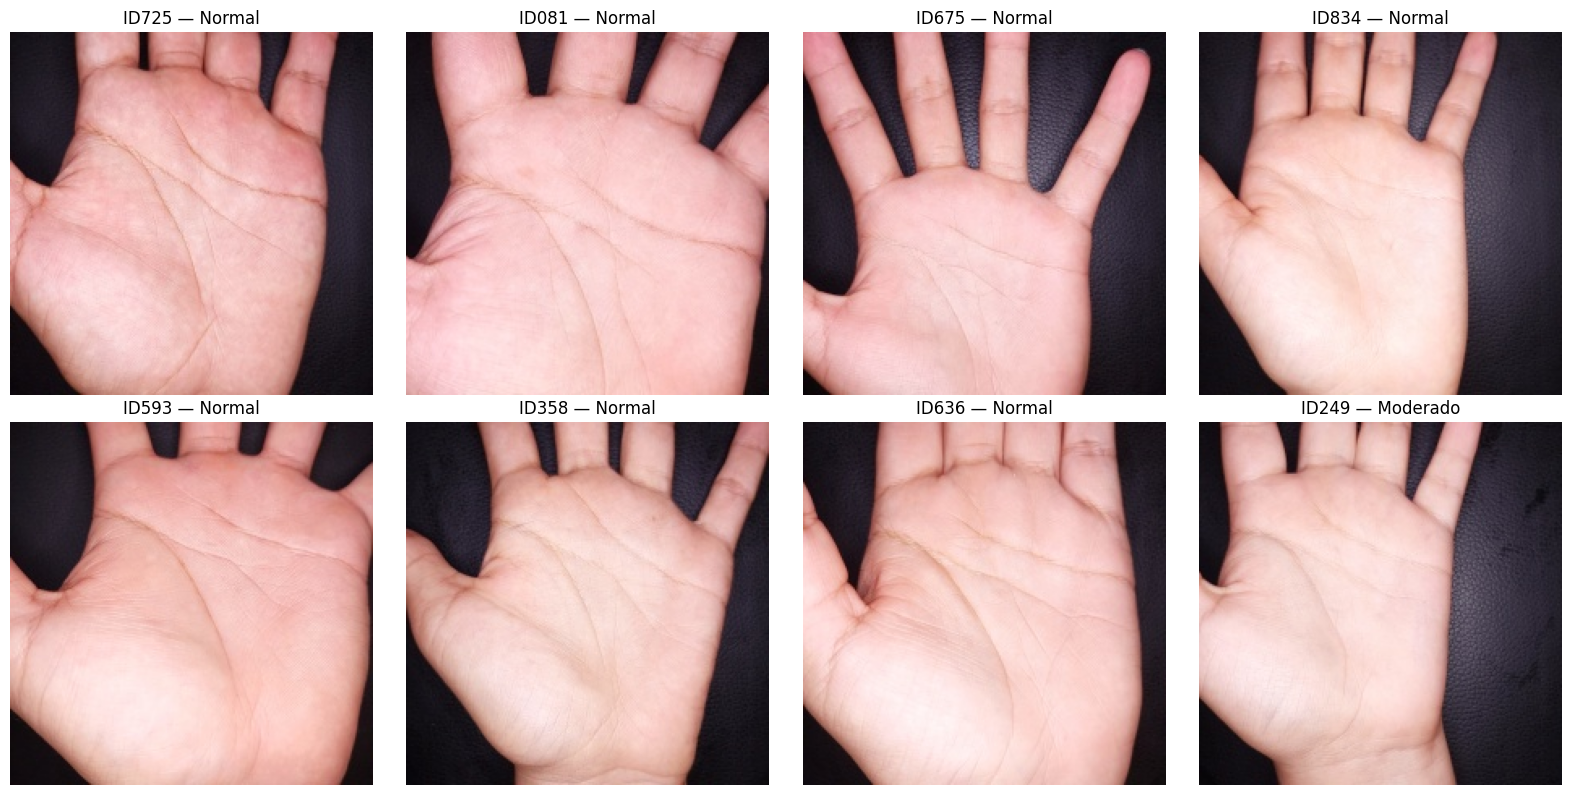

In [8]:
#Step 8  Visual Check: Final Cropped Outputs
sample = df_success.sample(8, random_state=5)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img = cv2.imread(row["final_path"])
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{row['patient_id']} — {row['class_name']}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [9]:
#Step 9  Artifact Detection Check (Dark Background Verification)
def has_box_artifact(img_path, dark_thresh=15, border_frac=0.05):
    img = cv2.imread(str(img_path))
    if img is None:
        return False
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    bh, bw = max(1, int(h * border_frac)), max(1, int(w * border_frac))
    top, bottom = gray[:bh, :], gray[-bh:, :]
    left, right = gray[:, :bw], gray[:, -bw:]
    border_pixels = np.concatenate([top.ravel(), bottom.ravel(), left.ravel(), right.ravel()])
    return (border_pixels < dark_thresh).mean() > 0.5

df_success["box_artifact"] = df_success["final_path"].apply(has_box_artifact)
summary = df_success.groupby("class_name")["box_artifact"].agg(["sum", "count"])
summary["pct"] = (summary["sum"] / summary["count"] * 100).round(1)
print(summary.sort_values("pct", ascending=False))

            sum  count  pct
class_name                 
Leve          0    201  0.0
Moderado      0     74  0.0
Normal        0    554  0.0


In [10]:
#Step 10  Final Summary & Save CSV
print(f"Final dataset: {len(df_success)} images (1 per patient) across {df_success['class_name'].nunique()} classes")
print(df_success["class_name"].value_counts())
print(f"\nImbalance ratio: {df_success['class_name'].value_counts().max() / df_success['class_name'].value_counts().min():.2f}x")

output_path = "/kaggle/working/peru_palm_final_clean.csv"
df_success.to_csv(output_path, index=False)
print(f"\nSaved -> {output_path}")

Final dataset: 829 images (1 per patient) across 3 classes
class_name
Normal      554
Leve        201
Moderado     74
Name: count, dtype: int64

Imbalance ratio: 7.49x

Saved -> /kaggle/working/peru_palm_final_clean.csv


In [11]:
#Step 11  Full Dataset Table View
display_df = df_success[["patient_id", "class_name", "folder_severity",
                          "box_artifact", "filename", "final_path"]].copy()
display_df = display_df.sort_values(["class_name", "patient_id"]).reset_index(drop=True)
print(f"Full dataset table ({len(display_df)} rows):\n")
pd.set_option("display.max_colwidth", 60)
display_df

Full dataset table (829 rows):



,patient_id,class_name,folder_severity,box_artifact,filename,final_path
0,ID004,Leve,Leve,False,ID004.mp4,/kaggle/working/peru_palm_final/Leve/ID004.jpg
1,ID015,Leve,Leve,False,ID015.mp4,/kaggle/working/peru_palm_final/Leve/ID015.jpg
2,ID018,Leve,Leve,False,ID018.mp4,/kaggle/working/peru_palm_final/Leve/ID018.jpg
3,ID019,Leve,Leve,False,ID019.mp4,/kaggle/working/peru_palm_final/Leve/ID019.jpg
4,ID020,Leve,Leve,False,ID020.mp4,/kaggle/working/peru_palm_final/Leve/ID020.jpg
...,...,...,...,...,...,...
824,ID890,Normal,Normal,False,ID890.mp4,/kaggle/working/peru_palm_final/Normal/ID890.jpg
825,ID891,Normal,Normal,False,ID891.mp4,/kaggle/working/peru_palm_final/Normal/ID891.jpg
826,ID892,Normal,Normal,False,ID892.mp4,/kaggle/working/peru_palm_final/Normal/ID892.jpg
827,ID894,Normal,Normal,False,ID894.mp4,/kaggle/working/peru_palm_final/Normal/ID894.jpg


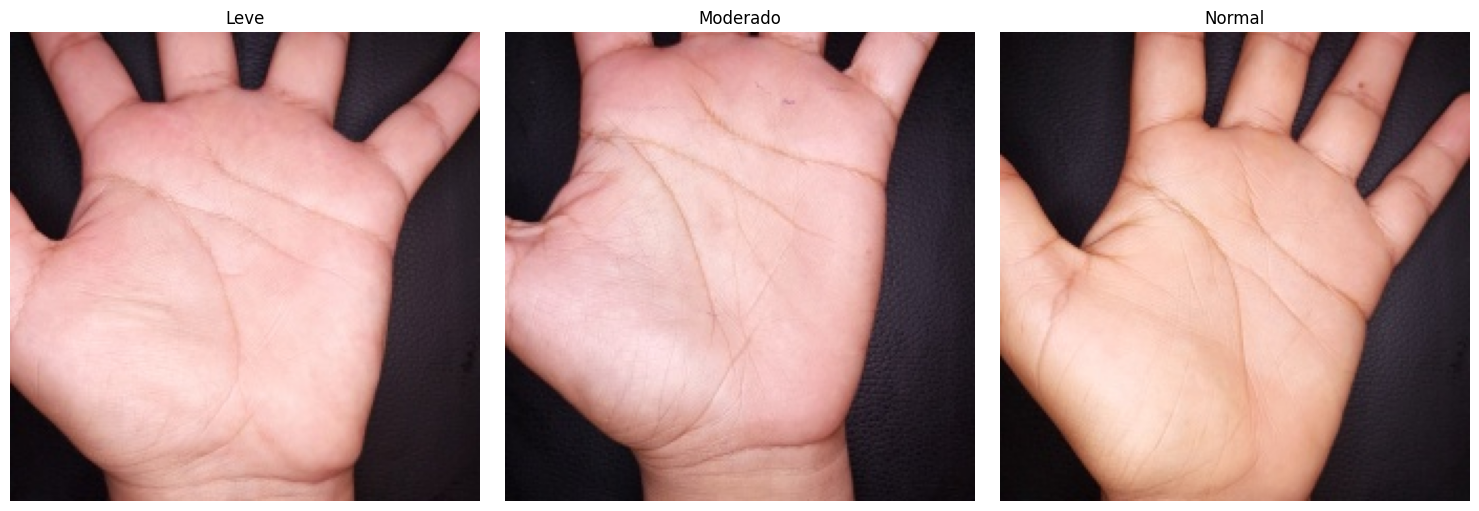

In [12]:
#Step 12  Random Sample Viewer (Per Class)
classes = sorted(df_success["class_name"].unique())
fig, axes = plt.subplots(1, len(classes), figsize=(5 * len(classes), 5))

for ax, cls in zip(axes, classes):
    row = df_success[df_success["class_name"] == cls].sample(1).iloc[0]
    img = cv2.imread(row["final_path"])
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()